# Sensor Telemetry — Exploratory Data Analysis

Dataset: 10,000 rows of synthetic sensor readings from 100 machines.  
Goal: Understand feature distributions, correlations, and differences between failed and healthy machines.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
%matplotlib inline

In [2]:
df = pd.read_csv("../data/sensor_telemetry.csv")
df.head()

,machine_id,temperature,vibration,pressure,rotational_speed,failure
0,52,76.94,1.5017,97.94,1471.96,0
1,93,45.22,0.0180,86.56,1619.62,0
2,15,89.10,0.6850,98.16,2042.00,0
3,72,69.16,0.5147,95.70,1654.16,0
4,61,55.94,0.1435,83.46,984.50,0


## Dataset Overview

In [3]:
print(f"Shape: {df.shape}")
df.info()

Shape: (10000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   machine_id        10000 non-null  int64  
 1   temperature       10000 non-null  float64
 2   vibration         10000 non-null  float64
 3   pressure          10000 non-null  float64
 4   rotational_speed  10000 non-null  float64
 5   failure           10000 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 468.9 KB


In [4]:
df.describe().round(2)

,machine_id,temperature,vibration,pressure,rotational_speed,failure
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,50.29,74.86,0.50,100.12,1501.14,0.05
std,28.87,15.15,0.50,19.73,298.15,0.22
min,1.00,30.00,0.00,50.00,500.00,0.00
25%,25.00,64.56,0.15,86.29,1293.57,0.00
50%,50.00,75.01,0.35,100.12,1498.72,0.00
75%,75.00,85.18,0.69,113.46,1705.11,0.00
max,100.00,120.00,4.61,170.12,2789.66,1.00


**Observations:**
- 10,000 samples across 6 columns — no missing values.
- `machine_id` ranges from 1 to 100, representing distinct machines.
- `temperature`: mean ~75°C, std ~15. Clipped between 30–120.
- `vibration`: exponential distribution, heavily right-skewed.
- `pressure`: normal around 100 psi, clipped 50–200.
- `rotational_speed`: normal around 1500 RPM, clipped 500–3000.
- `failure` is binary (0/1) — we'll check the balance next.

## Class Imbalance

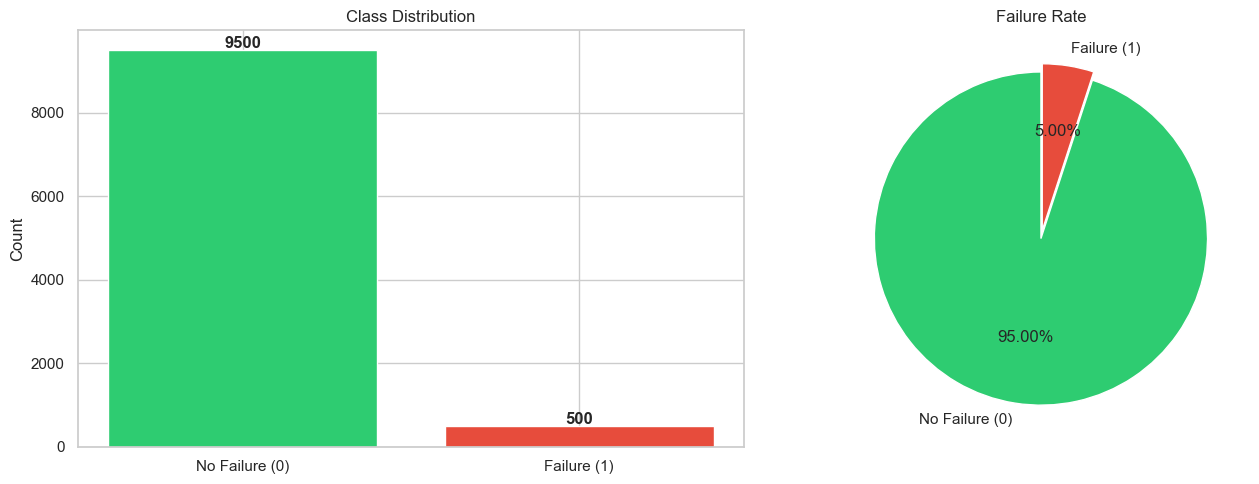

Failure rate: 5.00%


In [5]:
counts = df["failure"].value_counts()
labels = ["No Failure (0)", "Failure (1)"]
colors = ["#2ecc71", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels, counts.values, color=colors, edgecolor="white")
axes[0].set_ylabel("Count")
axes[0].set_title("Class Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

axes[1].pie(
    counts.values,
    labels=labels,
    autopct="%1.2f%%",
    colors=colors,
    explode=(0, 0.05),
    startangle=90,
)
axes[1].set_title("Failure Rate")

plt.tight_layout()
plt.show()
print(f"Failure rate: {df['failure'].mean():.2%}")

**Observations:**
- Dataset is **imbalanced** with a 5% failure rate (500 failures out of 10,000).
- This is realistic — most industrial equipment fails rarely.
- During modeling, we should use stratified splits, consider class weights, or apply SMOTE to handle imbalance.

## Feature Distributions

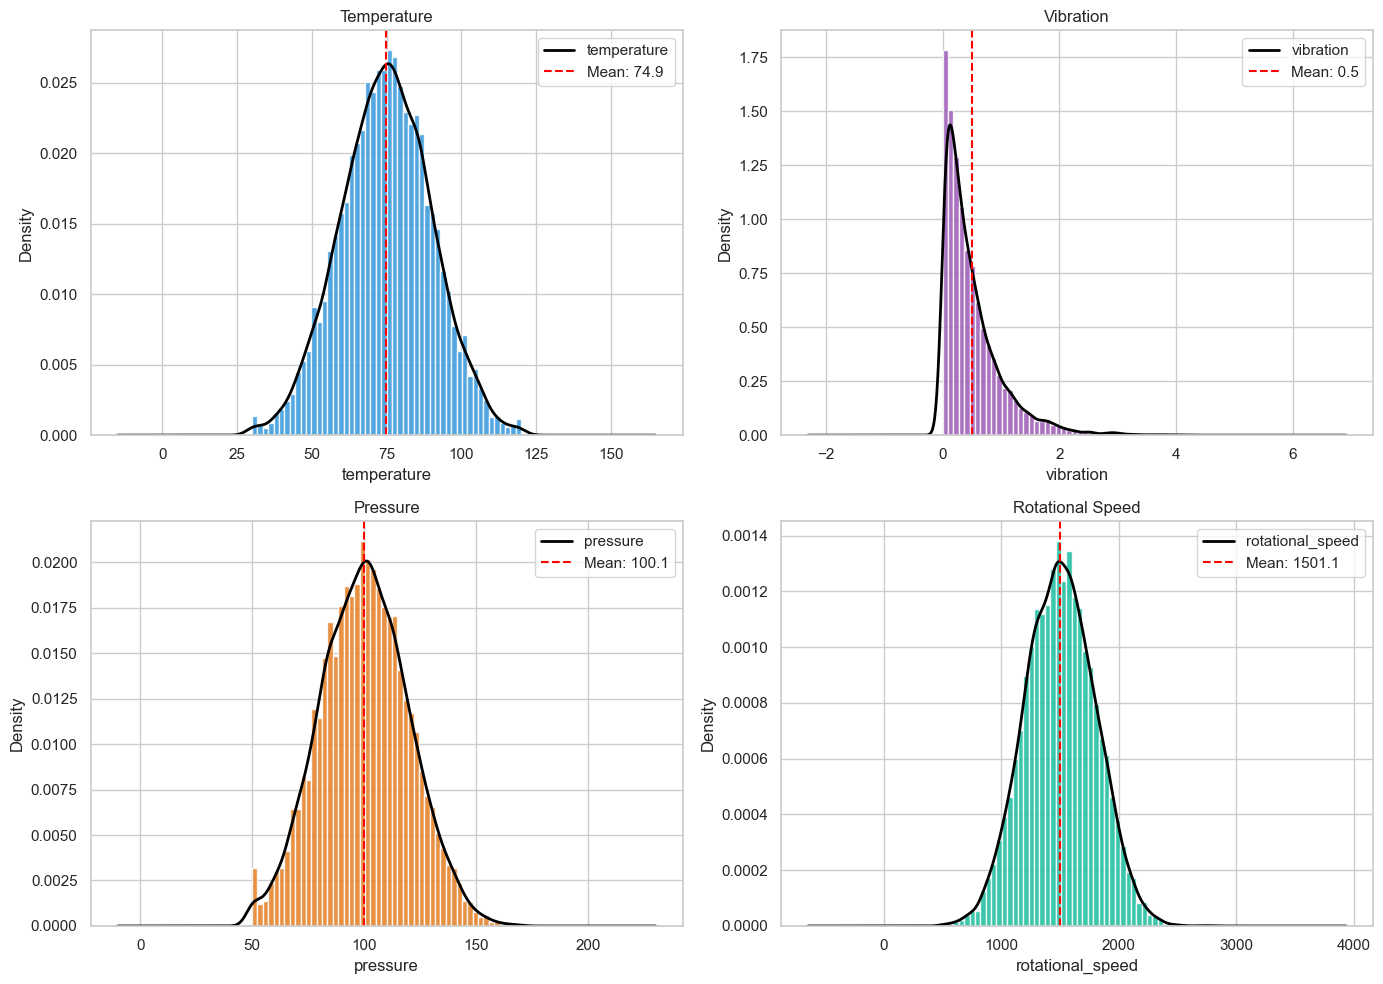

In [6]:
features = ["temperature", "vibration", "pressure", "rotational_speed"]
colors = ["#3498db", "#9b59b6", "#e67e22", "#1abc9c"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat, color) in enumerate(zip(features, colors)):
    axes[i].hist(df[feat], bins=50, color=color, edgecolor="white", alpha=0.85, density=True)
    df[feat].plot.kde(ax=axes[i], color="black", linewidth=2)
    mean_val = df[feat].mean()
    axes[i].axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.1f}")
    axes[i].set_title(feat.replace("_", " ").title())
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.tight_layout()
plt.show()

**Observations:**
- **Temperature**: roughly normal, centered around 75°C with slight right tail.
- **Vibration**: exponential/exponential-like — most readings are low, but a long tail of high-vibration events exists. High vibration is a known precursor to bearing failures.
- **Pressure**: symmetric normal around 100 psi, well-behaved.
- **Rotational Speed**: normal around 1500 RPM, some spread.
- No features show obvious multi-modality or outliers beyond the synthetic clipping bounds.

## Correlation Heatmap

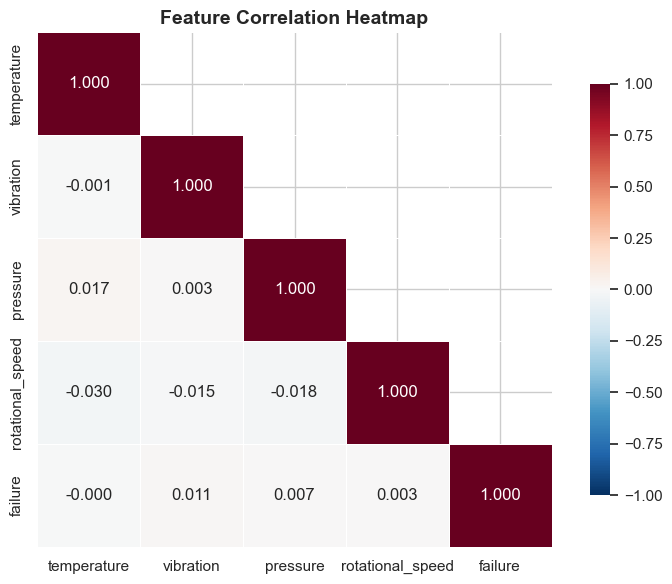

In [7]:
corr = df.drop(columns="machine_id").corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**
- All pairwise correlations among sensor features are **very close to zero** (< |0.02|).
- This is expected: the features were generated independently in the synthetic dataset.
- In real-world data, you'd expect some coupling (e.g., higher RPM → higher vibration).
- `failure` also has near-zero linear correlation with features — this means **linear separation is poor** and a nonlinear model (tree-based, neural net) will be needed.

## Feature Distributions by Failure Status

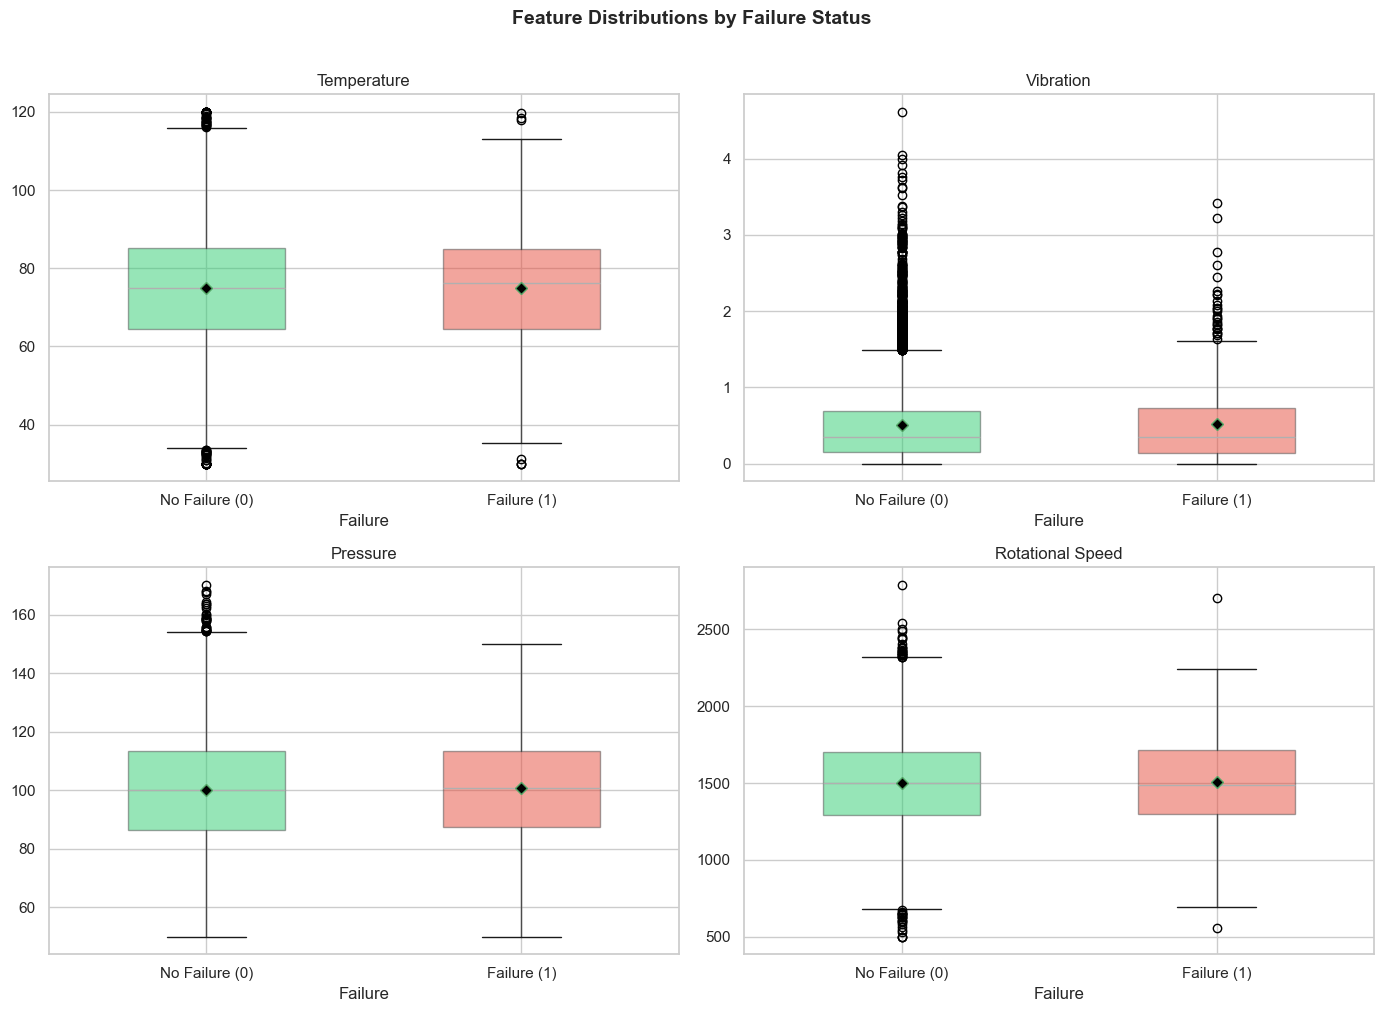

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
box_colors = ["#2ecc71", "#e74c3c"]

for i, feat in enumerate(features):
    bp = df.boxplot(
        column=feat,
        by="failure",
        ax=axes[i],
        patch_artist=True,
        widths=0.5,
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="black", markersize=6),
    )
    for patch, color in zip(axes[i].patches, box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    axes[i].set_title(feat.replace("_", " ").title())
    axes[i].set_xlabel("Failure")
    axes[i].set_xticklabels(["No Failure (0)", "Failure (1)"])

plt.suptitle("Feature Distributions by Failure Status", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- Since failures were assigned randomly (not driven by sensor values), the distributions for failure=0 and failure=1 are nearly identical.
- In a real predictive-maintenance scenario, you would expect failures to correlate with extreme sensor values (high vibration, high temperature, abnormal pressure/RPM).
- This synthetic dataset is best used as a **baseline** — realistic datasets would show clear separation in these boxplots.
- The black diamonds mark the mean; medians and IQR overlap heavily between classes.

## Summary

1. **No missing data** — ready for modeling without imputation.
2. **5% failure rate** — class imbalance must be handled with stratification, class weights, or resampling.
3. **Features are independent** — near-zero correlations; nonlinear models will be essential.
4. **No distributional differences by failure** — the random failure assignment means this dataset is a baseline. Replace with a real or semi-realistic dataset for production modeling.
5. **Feature ranges are consistent** — no normalization strictly required, but scaling helps distance-based models.